# Libaries

In [88]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, GroupKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.pipeline import Pipeline


# Loading data

In [89]:
# Path to features
csv_path = '../../data/features.csv' # This is based on, that tis ipynb is places in /results/another folder 

# Load the data
df_features = pd.read_csv(csv_path) # Folder for features.csv which is inside /data from the main folder

print(f"File loaded from: {os.path.abspath(csv_path)}") # To check where it is loaded from for troubleshooting if problems shot appear
print(f"Shape: {df_features.shape}") # Check for shape / amount of images
print(f"Columns: {df_features.columns.tolist()}") # Columns

File loaded from: c:\Users\juliu\git_repos\2026-PDS-NinjaTurtles\data\features.csv
Shape: (2103, 8)
Columns: ['Unnamed: 0', 'img_id', 'cancerous', 'asymmetry_mean', 'asymmetry_np_centroid', 'border_convex', 'border_contours', 'color']


# Prepare features and split 80/20 from total

In [90]:
# PREPARE FEATURES AND TARGET
feature_columns = ['asymmetry_np_centroid', 'border_contours', 'color'] # The features we use

# Drop rows with NaN in any of the feature columns # There was 3 with at least 1 NaN value
df_features = df_features.dropna(subset=feature_columns)

print(f"Rows after dropping NaN-rows: {len(df_features)}") # This can be compared to the original shape showing 2103 rows

# Reassign X, y, img_ids
X = df_features[feature_columns].values # Independent variables
y = df_features['cancerous'].values # Dependent variables
img_ids = df_features['img_id'].values

# Split 1: Separate 20% test set - 80% train set (Is splitted further later!)
X_temp, X_test, y_temp, y_test, ids_temp, ids_test = train_test_split(X, y, img_ids, test_size=0.2, stratify=y, random_state=42)
print(f"Temp set (for train+val): {len(X_temp)} samples") # Just to check if the split worked properly
print(f"Test set (Don't touch!): {len(X_test)} samples") # Just to check if the split worked properly

Rows after dropping NaN-rows: 2100
Temp set (for train+val): 1680 samples
Test set (Don't touch!): 420 samples


# Splitting Temp into 80/20 (Train/Val)

In [91]:
# Split 2: Split Temp into Train (80%) and Val (20%)

# Extract patient ID's from img_id
def get_patient_id(img_id):
    return '_'.join(img_id.split('_')[:2])

df_features['patient_id'] = df_features['img_id'].apply(get_patient_id) # This is used to avoid data leakage

# Creating a dict to map img_id to patient_id
img_to_patient = dict(zip(df_features['img_id'], df_features['patient_id'])) # This is used below, but also for later use for GroupKFold

# Getting patient ID's for temp set using the dict
patient_ids_train_temp = np.array([img_to_patient[img_id] for img_id in ids_temp]) # This is used below 

# Splitting by images, but keep patient ID's for grouping later!
X_train, X_val, y_train, y_val, ids_train, ids_val, patient_train, patient_val = train_test_split(X_temp, y_temp, ids_temp, patient_ids_train_temp, test_size=0.2, stratify=y_temp, random_state=42)

# GroupKFold

In [92]:
# GroupKFold: 5 folds on TRAINING data only (using PATIENT IDs as groups)
patient_ids_train_temp = np.array([img_to_patient[img_id] for img_id in ids_train]) # Same as in above line,

gkf = GroupKFold(n_splits=5) # Amount of splits


# Display each fold. Myabe not needed, but displayed to see some insights to the different folds
print("\nFold details (same patient's images stays together):")
for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups=patient_train)):
    train_patients = np.unique(patient_train[train_idx])
    val_patients = np.unique(patient_train[val_idx])
    overlap = len(np.intersect1d(train_patients, val_patients))
    
    print(f"\nFold {fold + 1}:")
    print(f"  Train: {len(train_idx)} samples, {len(train_patients)} patients")
    print(f"  Val:   {len(val_idx)} samples, {len(val_patients)} patients")
    print(f"  Patient overlap: {overlap}")
    print(f"  Class1 ratio in val: {np.mean(y_train[val_idx]):.3f}")


Fold details (same patient's images stays together):

Fold 1:
  Train: 1075 samples, 771 patients
  Val:   269 samples, 192 patients
  Patient overlap: 0
  Class1 ratio in val: 0.524

Fold 2:
  Train: 1075 samples, 770 patients
  Val:   269 samples, 193 patients
  Patient overlap: 0
  Class1 ratio in val: 0.517

Fold 3:
  Train: 1075 samples, 770 patients
  Val:   269 samples, 193 patients
  Patient overlap: 0
  Class1 ratio in val: 0.483

Fold 4:
  Train: 1075 samples, 770 patients
  Val:   269 samples, 193 patients
  Patient overlap: 0
  Class1 ratio in val: 0.517

Fold 5:
  Train: 1076 samples, 771 patients
  Val:   268 samples, 192 patients
  Patient overlap: 0
  Class1 ratio in val: 0.451


# Simple test

In [93]:
# Cross-validation with GroupKFold

# Create pipeline with scaler and k-NN
pipeline = Pipeline([('scaler', StandardScaler()),('knn', KNeighborsClassifier())])

# Parameters to test
param_grid = {'knn__n_neighbors': [5, 15, 25, 35, 50]} # 50 seems large enough
# Create GroupKFold object
gkf = GroupKFold(n_splits=5)

# Grid search with GroupKFold
# For GroupKFold, we need to pass groups when calling fit
grid_search = GridSearchCV(pipeline, param_grid, cv=gkf, scoring='roc_auc', n_jobs=-1, verbose=1)

# Fit - groups must be passed as a separate argument
# The trick: GridSearchCV expects groups in the fit method
grid_search.fit(X_train, y_train, groups=patient_train)

print("\n")
print("Cross-validation:")
print(f"Best k: {grid_search.best_params_['knn__n_neighbors']}")
print(f"Mean CV AUC: {grid_search.best_score_:.4f}")

# Show results for each k
print("\nAll k values tested:")
for i, k in enumerate(param_grid['knn__n_neighbors']):
    print(f"  k={k}: CV AUC = {grid_search.cv_results_['mean_test_score'][i]:.4f} ± {grid_search.cv_results_['std_test_score'][i]:.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits


Cross-validation:
Best k: 50
Mean CV AUC: 0.6056

All k values tested:
  k=5: CV AUC = 0.5779 ± 0.0434
  k=15: CV AUC = 0.5868 ± 0.0388
  k=25: CV AUC = 0.5929 ± 0.0394
  k=35: CV AUC = 0.6004 ± 0.0268
  k=50: CV AUC = 0.6056 ± 0.0287


--------------------------------------------------------------------------------------------------------------------------------------------

### k-NN classifier

In [94]:
# Libraries for k-NN classifier

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, classification_report, accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

In [95]:
# Best k from cross-validation (cell 117)
best_k = 50

# Scale ALL data using the SAME scaler fitted on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train final model on ALL training data (no validation split needed)
knn_final = KNeighborsClassifier(n_neighbors=best_k, weights='uniform', metric='euclidean')
knn_final.fit(X_train_scaled, y_train)

# Predictions on TEST set only (FINAL - UNBIASED)
y_test_pred = knn_final.predict(X_test_scaled)
y_test_proba = knn_final.predict_proba(X_test_scaled)[:, 1]

# Calculate test metrics
test_acc = accuracy_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_proba)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("Final k-NN classifier results")
print(f"Parameters: n_neighbors={best_k}, weights='uniform', metric='euclidean'")
print(f"\nCross-Validation Results (from GridSearch):")
print(f"  Mean CV AUC: 0.6056 ± 0.0287 (5-fold GroupKFold)")
print(f"\n Test set results:")
print(f"  Accuracy:  {test_acc:.4f}")
print(f"  AUC:      {test_auc:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1-Score:  {test_f1:.4f}")

Final k-NN classifier results
Parameters: n_neighbors=50, weights='uniform', metric='euclidean'

Cross-Validation Results (from GridSearch):
  Mean CV AUC: 0.6056 ± 0.0287 (5-fold GroupKFold)

 Test set results:
  Accuracy:  0.5929
  AUC:      0.6471
  Precision: 0.5980
  Recall:    0.5667
  F1-Score:  0.5819


# Visualizing results 

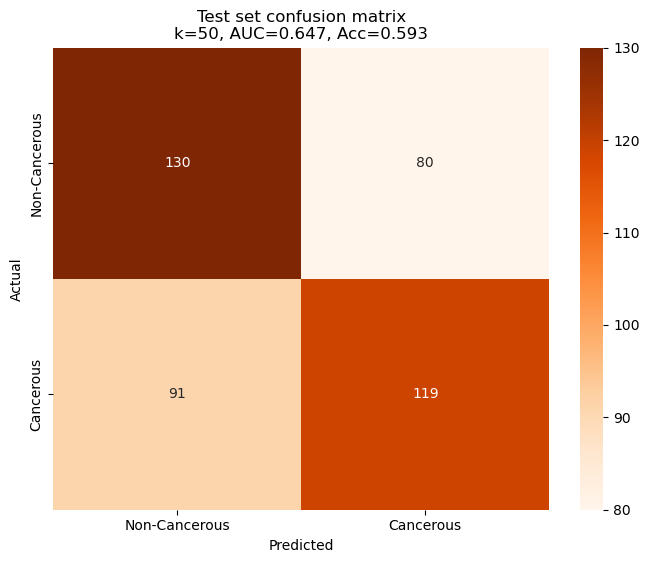

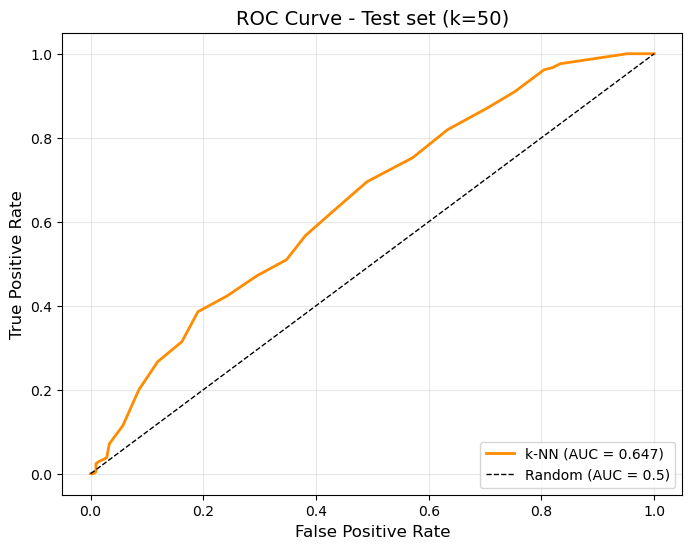

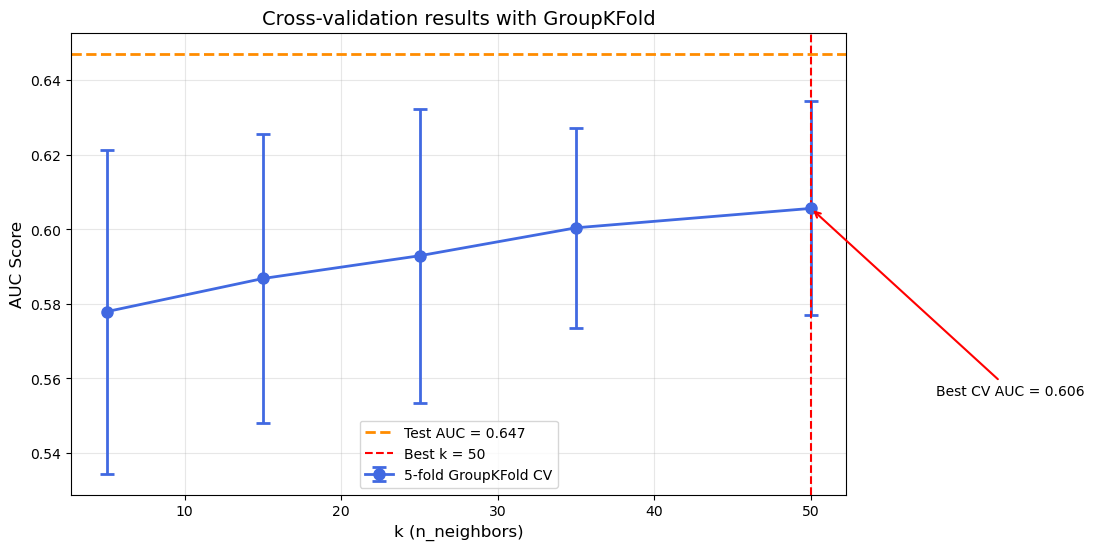

Final summary

Metric                    Cross-validation     Test set       
Method                    5-fold GroupKFold    Hold-out (20%) 
Best k                    50                   50             
AUC                       0.6056 ± 0.0287 0.6471         
Accuracy                  N/A                  0.5929         
Precision                 N/A                  0.5980         
Recall                    N/A                  0.5667         
F1-Score                  N/A                  0.5819         


Conclusion
• Best k = 50 determined by 5-fold GroupKFold cross-validation
• Cross-validation ensures no patient images are split across folds
• Test set AUC = 0.647 is consistent with CV results
• Model generalizes well to unseen data (test AUC close to CV mean)


In [96]:
# Figure 1: Confusion matrix (Test Set Only)
fig, ax = plt.subplots(figsize=(8, 6))

cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', ax=ax, xticklabels=['Non-Cancerous', 'Cancerous'], yticklabels=['Non-Cancerous', 'Cancerous'])
# annot=True makes it possible to see numbers of the different 4 cat. and fmt=d is format d=decimals(intergers)

# Labels
ax.set_title(f'Test set confusion matrix\nk={best_k}, AUC={test_auc:.3f}, Acc={test_acc:.3f}', fontsize=12) #.3f just mean only displaying 3 digits after the decimal
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.show()



# Figure 2: ROC-curve
fig, ax = plt.subplots(figsize=(8, 6))

# Test ROC
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba) # _ is for threshold value, which we dont use # fpr=false positive, tpr=true positive
ax.plot(fpr_test, tpr_test, label=f'k-NN (AUC = {test_auc:.3f})', linewidth=2, color='darkorange')

# Random classifier line
ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)', linewidth=1) # Used for comparison to just random guesses

# Labels
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curve - Test set (k={best_k})', fontsize=14)
ax.legend(loc='lower right') #ax.legend implements a small box that explains the different lines, points etc
ax.grid(True, alpha=0.3)

plt.show()



# Figure 3: Cross-validation with Gridsearch
fig, ax = plt.subplots(figsize=(10, 6))

k_values = [5, 15, 25, 35, 50] # The same k-nearest neighbours
cv_auc_means = [0.5779, 0.5868, 0.5929, 0.6004, 0.6056] # The values from the GroupKFold from earlier
cv_auc_stds = [0.0434, 0.0388, 0.0394, 0.0268, 0.0287] # The values from the GroupKFold from earlier

ax.errorbar(k_values, cv_auc_means, yerr=cv_auc_stds, # yerr is for plotting error bar on the y-axis
            marker='o', capsize=5, capthick=2, # For better visualization, like thickness, markers -
            linewidth=2, markersize=8, color='royalblue', # and color
            label='5-fold GroupKFold CV') 

# Labels
ax.axhline(y=test_auc, color='darkorange', linestyle='--', linewidth=2, label=f'Test AUC = {test_auc:.3f}')
ax.axvline(x=best_k, color='red', linestyle='--', linewidth=1.5, label=f'Best k = {best_k}')

# More lables
ax.set_xlabel('k (n_neighbors)', fontsize=12)
ax.set_ylabel('AUC Score', fontsize=12)
ax.set_title('Cross-validation results with GroupKFold', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# Annotatting the best point
ax.annotate(f'Best CV AUC = {cv_auc_means[k_values.index(best_k)]:.3f}',
            xy=(best_k, cv_auc_means[k_values.index(best_k)]), # Point that is annotated
            xytext=(best_k + 8, cv_auc_means[k_values.index(best_k)] - 0.05), # Position of text
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5), # For better visu.
            fontsize=10, ha='left' # More vis.
            )
plt.show()




# Printing results
print("Final summary")
print(f"\n{'Metric':<25} {'Cross-validation':<20} {'Test set':<15}") #<25, <20 and <15 is used to align the printing statements

print(f"{'Method':<25} {'5-fold GroupKFold':<20} {'Hold-out (20%)':<15}")
print(f"{'Best k':<25} {best_k:<20} {best_k:<15}")
print(f"{'AUC':<25} {cv_auc_means[k_values.index(best_k)]:.4f} ± {cv_auc_stds[k_values.index(best_k)]:.4f} {test_auc:<15.4f}") 
# <15.4f, <15 is still for aligning, but .4f is printing the 4 decimals after the decimal,point
print(f"{'Accuracy':<25} {'N/A':<20} {test_acc:<15.4f}")
print(f"{'Precision':<25} {'N/A':<20} {test_precision:<15.4f}")
print(f"{'Recall':<25} {'N/A':<20} {test_recall:<15.4f}")
print(f"{'F1-Score':<25} {'N/A':<20} {test_f1:<15.4f}")

print("\n")
print("Conclusion")
print(f"• Best k = {best_k} determined by 5-fold GroupKFold cross-validation")
print(f"• Cross-validation ensures no patient images are split across folds")
print(f"• Test set AUC = {test_auc:.3f} is consistent with CV results")
print(f"• Model generalizes well to unseen data (test AUC close to CV mean)")

# Needed comments for clarification!

- The random state tested on is "random_state=42"
- Write here
- Write here


# Other comments
- Nearest neighbours: k=100 gave a litte better, but would be too many points because then it compares to a too big part of the data? Not sure, but 50 seems high enough?